In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
df = pd.read_csv(r"C:\Users\khush\OneDrive\Desktop\House-Price-Prediction\data\AmesHousing.csv")

print(df.head())
print(df.shape)

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [19]:
features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "Year Built",
    "Full Bath",
    "TotRms AbvGrd"
]

X = df[features]
y = df["SalePrice"]

In [20]:
X = X.fillna(X.mean())

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
linear = LinearRegression()

linear.fit(X_train, y_train)

linear_pred = linear.predict(X_test)

In [23]:
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [24]:
print("----------- Linear Regression -----------")

print("R2 Score :", round(r2_score(y_test, linear_pred),4))

print("MSE :", round(mean_squared_error(y_test, linear_pred),2))

print("RMSE :", round(np.sqrt(mean_squared_error(y_test, linear_pred)),2))


print("\n----------- Ridge Regression -----------")

print("R2 Score :", round(r2_score(y_test, ridge_pred),4))

print("MSE :", round(mean_squared_error(y_test, ridge_pred),2))

print("RMSE :", round(np.sqrt(mean_squared_error(y_test, ridge_pred)),2))

----------- Linear Regression -----------
R2 Score : 0.798
MSE : 1619157743.08
RMSE : 40238.76

----------- Ridge Regression -----------
R2 Score : 0.7981
MSE : 1618929259.51
RMSE : 40235.92


In [25]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": linear.coef_,
    "Ridge Regression": ridge.coef_
})

print(coef)

         Feature  Linear Regression  Ridge Regression
0   Overall Qual       20579.105939      20482.438414
1    Gr Liv Area          61.897351         61.874380
2    Garage Cars        7712.201766       7421.533397
3    Garage Area          24.276864         25.194804
4  Total Bsmt SF          26.643257         26.686374
5     Year Built         364.348784        365.814508
6      Full Bath       -5881.492180      -5679.099358
7  TotRms AbvGrd       -3097.865601      -3089.866599


In [26]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Prediction": linear_pred,
    "Ridge Prediction": ridge_pred
})

print(result.head(10))

   Actual Price  Linear Prediction  Ridge Prediction
0        161000      190154.897569     189765.086899
1        116000      128221.729605     128129.746420
2        196500      215279.107790     215383.811511
3        123600       94794.924254      94991.159977
4        126000      116671.144412     116460.197551
5        174190      186886.232604     186934.506680
6        200000      208034.374273     207712.956009
7        148500      168671.184267     168672.124542
8         88750       64297.916975      64315.106865
9        409900      307655.014930     307428.688606


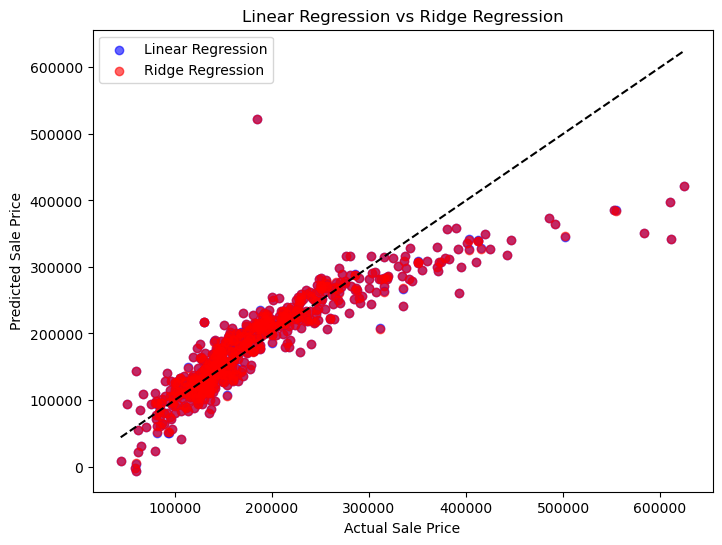

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, linear_pred,
            color="blue",
            alpha=0.6,
            label="Linear Regression")

plt.scatter(y_test, ridge_pred,
            color="red",
            alpha=0.6,
            label="Ridge Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Linear Regression vs Ridge Regression")
plt.legend()
plt.show()

In [28]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Ridge Regression"],
    "R2 Score":[
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred))
    ]
})

print(comparison)

               Model  R2 Score          RMSE
0  Linear Regression  0.798048  40238.759214
1   Ridge Regression  0.798077  40235.920016
